# Multi-Asset Allocation

## Data

This problem uses `weekly` data from `data/asset_class_etf_data.xlsx`.
* tab `excess returns`: weekly returns net of cash (`SHV`)
* tab `descriptions`: what each ticker holds

One fund per asset class, built across the course:
* equities: `SPY`, `VEA`
* bonds and credit: `IEF`, `HYG`
* commodities: `GLD`, `USO`
* crypto: `BTC`

`BTC` is the spot bitcoin series. It became investable in ETF form in late 2021 (`BITO`, futures-based) and via spot ETFs (`IBIT`, `FBTC`) in January 2024. The out-of-sample window below starts in 2022: the ETF era.

Annualize weekly stats with a factor of `52`.

# 1 The Asset Menu

## 1.1

For each asset, calculate over the full sample the annualized
* mean
* volatility
* Sharpe ratio

## 1.2

Report the correlation matrix.

Which asset offers the most diversification against `SPY`?

## 1.3

Report each asset's empirical VaR (.05) of weekly returns.

Which assets carry the most tail risk?

,Annualized Return,Annualized Excess Return,Annualized Volatility,Sharpe Ratio
SPY,0.138232,0.138214,0.174663,0.791322
VEA,0.081996,0.081978,0.173244,0.473192
IEF,-0.008569,-0.008587,0.063641,-0.134930
HYG,-0.004677,-0.004695,0.096553,-0.048625
GLD,0.138651,0.138633,0.151405,0.915641
USO,0.099176,0.099158,0.409988,0.241856
BTC,0.675898,0.675880,0.687931,0.982482


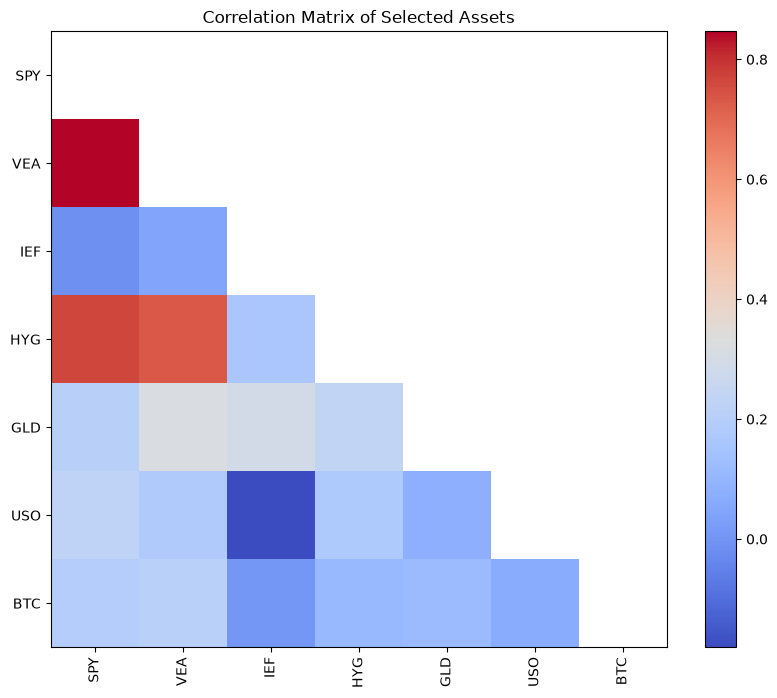

SPY   -0.032704
VEA   -0.034911
IEF   -0.015835
HYG   -0.015587
GLD   -0.031070
USO   -0.082074
BTC   -0.137061
Name: 0.05, dtype: float64

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1.1
prices = pd.read_excel('./data/asset_class_etf_data.xlsx', sheet_name='prices', index_col=0).drop(columns=["SHV"])
all_returns = pd.read_excel('./data/asset_class_etf_data.xlsx', sheet_name='total returns', index_col=0)
returns = all_returns.drop(columns=["SHV"])
shv_returns = all_returns["SHV"]
excess = pd.read_excel('./data/asset_class_etf_data.xlsx', sheet_name='excess returns', index_col=0)

# Calculate annualized numbers
annualized_returns = returns.mean() * 52
annualized_excess_returns = excess.mean() * 52
annualized_volatility = returns.std() * np.sqrt(52)
sharpe_ratio = annualized_excess_returns / annualized_volatility

# Table to present results
results = pd.DataFrame({
    'Annualized Return': annualized_returns,
    'Annualized Excess Return': annualized_excess_returns,
    'Annualized Volatility': annualized_volatility,
    'Sharpe Ratio': sharpe_ratio
})

display(results)

# 1.2 correlation matrix by heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = returns.corr()
# Create a mask to show only the lower triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
# Apply the mask and plot
plt.imshow(correlation_matrix.mask(mask), cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)
plt.title('Correlation Matrix of Selected Assets')
plt.show()
mask

#1.3 Report each asset's empirical VaR (.05) of weekly returns.
var_05 = returns.quantile(0.05)
display(var_05)

**Answer 1.2:** IEF offers the most diversification against SPY.

**Answer 1.3:** Overall, USO and BTC has the most tail risk with VaR 0.05 being -0.082 and -0.137.

***

# 2 Simple Rules

Two portfolios that require no optimization:
* equally-weighted across the 7 assets, rebalanced weekly
* `60/40`: 60% `SPY`, 40% `IEF`, rebalanced weekly

## 2.1

For each, report the annualized mean, volatility, and Sharpe over the full sample.

## 2.2

Report each portfolio's empirical VaR (.05). Compare to the individual assets in 1.3.

In [14]:
# Initialize portfolio weights for each strategy
# Portfolio A: Equally-weighted, rebalanced weekly
weights_A = pd.Series([1/len(returns.columns)] * len(returns.columns), index=returns.columns)
# Portfolio B: 60%SPY, 40% IEF, rebalanced weekly
weights_B = pd.Series([0.6, 0, 0.4] + [0] * (len(returns.columns) - 3), index=returns.columns)

# Calculate weekly portfolio returns
portfolio_returns = pd.DataFrame({
    "Equal Weight": returns @ weights_A,
    "60/40 SPY/IEF": returns @ weights_B
})

portfolio_excess = pd.DataFrame({
    "Equal Weight": excess @ weights_A,
    "60/40 SPY/IEF": excess @ weights_B
})

# 2.1 Metrics
portfolio_cagr = portfolio_returns.mean() * 52
portfolio_excess_returns = portfolio_excess.mean() * 52
portfolio_volatility = portfolio_returns.std() * np.sqrt(52)

portfolio_metrics = pd.DataFrame({
    "Annualized Return": portfolio_cagr,
    "Annualized Excess Return": portfolio_excess_returns,
    "Annualized Volatility": portfolio_volatility,
    "Sharpe Ratio": portfolio_excess_returns / portfolio_volatility
})
display(portfolio_metrics)

# 2.2 Empirical weekly VaR at 5%
portfolio_var_05 = portfolio_returns.quantile(0.05)
display(portfolio_var_05)

,Annualized Return,Annualized Excess Return,Annualized Volatility,Sharpe Ratio
Equal Weight,0.058923,0.058771,0.126648,0.464047
60/40 SPY/IEF,0.106298,0.106146,0.105550,1.005646


Equal Weight    -0.028594
60/40 SPY/IEF   -0.021378
Name: 0.05, dtype: float64

**Answer 2.2:** The diversified portfolios have much less tail risk using VaR 0.05 as the metric, compared to the individual assets (excpet for IEF and HYG, which are bonds). The equal weight portfolio even has an annualized mean return higher than all assets except BTC with such small tail risk. 

***

# 3 Mean-Variance Optimization

Estimate using data **through 2021 only**. (2022 onward is held out for Section 5.)

Exclude `BTC` for this section: the menu is the 6 traditional assets.

## 3.1

Calculate the tangency portfolio weights.

$$
\mathbf{w}_{\mathrm{tan}}
=
\frac{\Sigma^{-1}\mu}
{\mathbf{1}^{\top}\Sigma^{-1}\mu}
$$

## 3.2

Do the weights look like a portfolio you could hold? Note any extreme or short positions.

## 3.3

Report the in-sample (through 2021) annualized mean, volatility, and Sharpe of the tangency portfolio, alongside the equal-weight and `60/40` portfolios over the same window.

In [15]:
# keep only data through 2021 without BTC
returns_part3 = returns.copy().drop(columns = "BTC").drop(returns[returns.index.year > 2021].index)
excess_part3 = excess.copy().drop(columns = "BTC").drop(excess[excess.index.year > 2021].index)
annualized_returns_part3 = returns_part3.mean() * 52 # number

# 3.1 Tangency portfolio weights
cov_matrix = returns_part3.cov() * 52  # Annualized covariance matrix
inv_cov_matrix = np.linalg.inv(cov_matrix)
tangency_weights = inv_cov_matrix @ annualized_returns_part3 / (np.ones(len(annualized_returns_part3)) @ inv_cov_matrix @ annualized_returns_part3)
print(pd.DataFrame(tangency_weights, index=annualized_returns_part3.index, columns=["Weights"]))

# 3.2 See below

# 3.3 Recalculate all comparison portfolios over the same through-2021 window
benchmark_weights_part3 = pd.DataFrame({
    "Equal Weight": 1 / len(returns_part3.columns),
    "60/40 SPY/IEF": 0.0
}, index=returns_part3.columns)
benchmark_weights_part3.loc["SPY", "60/40 SPY/IEF"] = 0.60
benchmark_weights_part3.loc["IEF", "60/40 SPY/IEF"] = 0.40

benchmark_returns_part3 = returns_part3 @ benchmark_weights_part3
benchmark_excess_part3 = excess_part3 @ benchmark_weights_part3

portfolio_metrics_part3 = pd.DataFrame({
    "Annualized Return": benchmark_returns_part3.mean() * 52,
    "Annualized Excess Return": benchmark_excess_part3.mean() * 52,
    "Annualized Volatility": benchmark_returns_part3.std() * np.sqrt(52)
})
portfolio_metrics_part3["Sharpe Ratio"] = (
    portfolio_metrics_part3["Annualized Excess Return"]
    / portfolio_metrics_part3["Annualized Volatility"]
)

# Calculate the expected return and volatility of the tangency portfolio
tangency_returns = (returns_part3 @ tangency_weights).mean() * 52
tangency_excess = (excess_part3 @ tangency_weights).mean() * 52
tangency_volatility = (returns_part3 @ tangency_weights).std() * np.sqrt(52)
tangency_sharpeRatio = tangency_excess / tangency_volatility

portfolio_metrics_part3.loc["Tangency (ex-BTC)"] = {
    "Annualized Return": tangency_returns,
    "Annualized Excess Return": tangency_excess,
    "Annualized Volatility": tangency_volatility,
    "Sharpe Ratio": tangency_sharpeRatio
}

display(portfolio_metrics_part3)



      Weights
SPY  1.983906
VEA -0.827804
IEF  1.053631
HYG -1.567881
GLD  0.403882
USO -0.045735


,Annualized Return,Annualized Excess Return,Annualized Volatility,Sharpe Ratio
Equal Weight,0.160101,0.160083,0.151766,1.054803
60/40 SPY/IEF,0.079512,0.079494,0.107530,0.739274
Tangency (ex-BTC),0.311041,0.310890,0.170346,1.825053


**Answer 3.2:** This is a mathematically feasible portfolio despite the high leverage in both long and short positions. The portfolio longs SPY with 198% weights, which is almost a 2x leverge, and shorting assets like VEA, HYG, and USO. Even though the portfolio sums to 1, it is not practical especially for retail investors since brokers would not allow an exposure over 500%, short and long together. 

***

# 4 A New Asset Class

Now add `BTC` to the menu. Still estimating through 2021 only.

## 4.1

Recalculate the tangency weights with all 7 assets.

How large is the `BTC` allocation?

## 4.2

Using `BTC`'s through-2021 mean, volatility, and correlations, explain why the optimizer sizes it the way it does.

## 4.3

Would you take this allocation to an investment committee? What would you have to believe about the *future* mean of `BTC` for it to be justified?

In [16]:
import pandas as pd
import numpy as np

# 4.1
excess = pd.read_excel('./data/asset_class_etf_data.xlsx', sheet_name='excess returns', index_col=0)

excess_2021 = excess[excess.index.year <= 2021]

mu = excess_2021.mean() * 52
Sigma = excess_2021.cov() * 52

w_tan = np.linalg.solve(Sigma, mu)
w_tan = w_tan / w_tan.sum()
tangency_weights = pd.Series(w_tan, index=excess_2021.columns, name="Tangency Weight")

display(tangency_weights.to_frame())
print(f"BTC allocation: {tangency_weights['BTC']:.2%}")


# 4.2
stats_2021 = pd.DataFrame({
    "Annualized Mean": excess_2021.mean() * 52,
    "Annualized Volatility": excess_2021.std() * np.sqrt(52),
})
stats_2021["Sharpe Ratio"] = stats_2021["Annualized Mean"] / stats_2021["Annualized Volatility"]
display(stats_2021)
display(excess_2021.corr())

sensitivity = {}
for assumed_mean in [mu["BTC"], 0.60, 0.40, 0.20, 0.10, 0.05, 0.0]:
    mu_adj = mu.copy()
    mu_adj["BTC"] = assumed_mean
    w_adj = np.linalg.solve(Sigma, mu_adj)
    w_adj = w_adj / w_adj.sum()
    sensitivity[assumed_mean] = pd.Series(w_adj, index=excess_2021.columns)["BTC"]

sensitivity = pd.Series(sensitivity, name="BTC Weight")
sensitivity.index.name = "Assumed BTC Forward Mean"
display(sensitivity.to_frame())

,Tangency Weight
SPY,2.023425
VEA,-1.112864
IEF,1.008836
HYG,-1.302694
GLD,0.289217
USO,-0.056611
BTC,0.150690


BTC allocation: 15.07%


,Annualized Mean,Annualized Volatility,Sharpe Ratio
SPY,0.164149,0.181648,0.903670
VEA,0.077783,0.176182,0.441493
IEF,0.019142,0.049222,0.388885
HYG,0.005675,0.112726,0.050347
GLD,0.094034,0.134666,0.698280
USO,-0.008159,0.432932,-0.018846
BTC,1.113800,0.809196,1.376428


,SPY,VEA,IEF,HYG,GLD,USO,BTC
SPY,1.000000,0.894335,-0.247141,0.789724,0.267206,0.355797,0.139596
VEA,0.894335,1.000000,-0.209488,0.756662,0.322980,0.380662,0.213293
IEF,-0.247141,-0.209488,1.000000,-0.094461,0.411001,-0.172556,0.012909
HYG,0.789724,0.756662,-0.094461,1.000000,0.330096,0.276873,0.066974
GLD,0.267206,0.322980,0.411001,0.330096,1.000000,0.069600,0.162512
USO,0.355797,0.380662,-0.172556,0.276873,0.069600,1.000000,0.107944
BTC,0.139596,0.213293,0.012909,0.066974,0.162512,0.107944,1.000000


,BTC Weight
Assumed BTC Forward Mean,
1.1138,0.150690
0.6000,0.072908
0.4000,0.042259
0.2000,0.011399
0.1000,-0.004111
0.0500,-0.011886
0.0000,-0.019675


**Answer 4.1**

The BTC allocation in the portfolio is 15.07%.


**Answer 4.2**

Through 2021, BTC has by far the highest excess mean, and even though its volatility is the highest in the set, its large mean gives it the best  Sharpe. Additionally, it's  uncorrelated with everything else, so it adds almost no risk to the portfolio. High risk adjusted return plus low correlation makes BTC heavily weighted by a mean-variance optimization system. 

**Answer 4.3**
No as the allocation is mostly weighted by BTC's 111%/year historical mean which is extremely backward looking. A defensible pitch would use a defendable forward assumption for the mean.



***

# 5 Out of Sample

Hold the weights estimated through 2021 fixed. Evaluate on 2022 through mid-2026: the ETF era.

## 5.1

For four portfolios,
* tangency (ex-`BTC`)
* tangency (with `BTC`)
* equal-weight
* `60/40`

report the out-of-sample annualized mean, volatility, and Sharpe.

## 5.2

Compare the in-sample and out-of-sample rankings. Which portfolio would you actually have wanted to hold?

## 5.3

Does the out-of-sample result vindicate or indict the optimizer? Careful: one out-of-sample window is itself a small sample.

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd

ANN = 52
ASSETS6 = ["SPY", "VEA", "IEF", "HYG", "GLD", "USO"]
ASSETS7 = ASSETS6 + ["BTC"]

_candidates = [
    Path("/Users/christophermo/Downloads/asset_class_etf_data.xlsx"),
    Path("data/asset_class_etf_data.xlsx"),
    Path("../data/asset_class_etf_data.xlsx"),
    Path("/Users/christophermo/Desktop/FINM-Quizzes/data/asset_class_etf_data.xlsx"),
]
FILEDATA = next(p for p in _candidates if p.exists())

rx = pd.read_excel(FILEDATA, sheet_name="excess returns", index_col="Date", parse_dates=True)
rx_is = rx.loc[: "2021-12-31"]
rx_oos = rx.loc["2022-01-01":]

def tangency_weights(excess, tickers):
    mu = excess[tickers].mean().values
    Sig = excess[tickers].cov().values
    raw = np.linalg.inv(Sig) @ mu
    return pd.Series(raw / raw.sum(), index=tickers)

def port_excess(excess, weights):
    w = weights.reindex(excess.columns).fillna(0.0)
    return excess.mul(w, axis=1).sum(axis=1)

def ann_stats(r):
    mu = r.mean() * ANN
    vol = r.std(ddof=1) * np.sqrt(ANN)
    return pd.Series({"mean": mu, "vol": vol, "Sharpe": mu / vol})

w_tan_ex = tangency_weights(rx_is, ASSETS6)
w_tan_btc = tangency_weights(rx_is, ASSETS7)
w_ew = pd.Series(1 / 7, index=ASSETS7)
w_6040 = pd.Series(0.0, index=ASSETS7)
w_6040["SPY"] = 0.60
w_6040["IEF"] = 0.40

portfolios = {
    "tangency (ex-BTC)": w_tan_ex,
    "tangency (with BTC)": w_tan_btc,
    "equal-weight": w_ew,
    "60/40": w_6040,
}

# 5.1 OOS stats
oos_stats = pd.DataFrame({name: ann_stats(port_excess(rx_oos, w)) for name, w in portfolios.items()}).T
display(oos_stats)

# 5.2 IS vs OOS rankings
is_stats = pd.DataFrame({name: ann_stats(port_excess(rx_is, w)) for name, w in portfolios.items()}).T
compare = pd.concat({"in-sample (<=2021)": is_stats, "out-of-sample (>=2022)": oos_stats}, axis=1)
display(compare)
print("Sharpe rank IS :", list(is_stats["Sharpe"].sort_values(ascending=False).index))
print("Sharpe rank OOS:", list(oos_stats["Sharpe"].sort_values(ascending=False).index))


,mean,vol,Sharpe
tangency (ex-BTC),0.193785,0.203126,0.954014
tangency (with BTC),0.176913,0.223787,0.790541
equal-weight,0.105187,0.123875,0.849143
60/40,0.049880,0.109024,0.457513


in-sample (<=2021)                      \
                                  mean       vol    Sharpe   
tangency (ex-BTC)             0.309401  0.169666  1.823586   
tangency (with BTC)           0.452996  0.203569  2.225271   
equal-weight                  0.209489  0.172727  1.212831   
60/40                         0.106146  0.105856  1.002742   

                    out-of-sample (>=2022)                      
                                      mean       vol    Sharpe  
tangency (ex-BTC)                 0.193785  0.203126  0.954014  
tangency (with BTC)               0.176913  0.223787  0.790541  
equal-weight                      0.105187  0.123875  0.849143  
60/40                             0.049880  0.109024  0.457513

Sharpe rank IS : ['tangency (with BTC)', 'tangency (ex-BTC)', 'equal-weight', '60/40']
Sharpe rank OOS: ['tangency (ex-BTC)', 'equal-weight', 'tangency (with BTC)', '60/40']


**Answer 5.1 — Out-of-sample (2022 → mid-2026), annualized excess returns**

| Portfolio | Mean | Vol | Sharpe |
|--|--|--|--|
| tangency (ex-BTC) | 19.38% | 20.31% | 0.954 |
| tangency (with BTC) | 17.69% | 22.38% | 0.791 |
| equal-weight | 10.52% | 12.39% | 0.849 |
| 60/40 | 4.99% | 10.90% | 0.458 |

**Answer 5.2 — IS vs OOS rankings**

In-sample Sharpe ranking (through 2021): **tangency (with BTC) > tangency (ex-BTC) > equal-weight > 60/40**

Out-of-sample Sharpe ranking (2022+): **tangency (ex-BTC) > equal-weight > tangency (with BTC) > 60/40**

In sample, the optimizer (especially **with BTC**) looks best — it was fit to that history. Out of sample that edge fades: **tangency with BTC drops**, and simple **equal-weight** looks competitive.

I would hold the OOS winner: **tangency (ex-BTC)** (highest realized Sharpe after 2021). I would *not* have wanted to trust the IS “with BTC” tangency just because it won the backtest.


**Answer 5.3 — Vindicate or indict the optimizer?**

Mostly **indicts unconstrained mean-variance optimism**: weights estimated through 2021 (extreme long/short mix, meaningful BTC) did **not** keep their impressive in-sample Sharpe when out of sample.

But be careful: **one OOS window is a small sample** (2022 rate shock, then equity/crypto rebound). That is not enough to “prove mean-variance optimization never works,” only that **these** IS tangency weights were fragile.

Practical takeaway I would conclude: treat optimized weights as noisy estimates; equal-weight / 60/40 are strong benchmarks because they do not overfit one mean vector.




***

# 6 Fragility

## 6.1

Re-estimate the tangency weights (all 7 assets) on rolling 3-year (156-week) windows. Plot the weights through time.

## 6.2

Estimate the tangency weights on two subsamples: 2017-2019 and 2020-2021. Report both sets side by side.

## 6.3

The math of mean-variance is exact; the inputs are estimates.
* Which input is the bigger problem: the means or the covariance matrix?
* Given 6.1 and 6.2, why do practitioners constrain weights, shrink estimates, or fall back to simple rules?

,SPY,VEA,IEF,HYG,GLD,USO,BTC
Date,,,,,,,
2020-01-03,7.602858,-2.681751,3.041377,-10.586725,2.996197,0.229605,0.398440
2020-01-10,9.975409,-3.905504,3.715147,-13.160063,3.561113,0.267716,0.546181
2020-01-17,7.007618,-2.543943,3.171506,-9.480480,2.273372,0.197562,0.374364
2020-01-24,8.334950,-3.071655,3.807934,-11.610369,2.954924,0.166801,0.417416
2020-01-31,5.187196,-2.136179,2.702659,-6.771118,1.680484,0.072586,0.264373


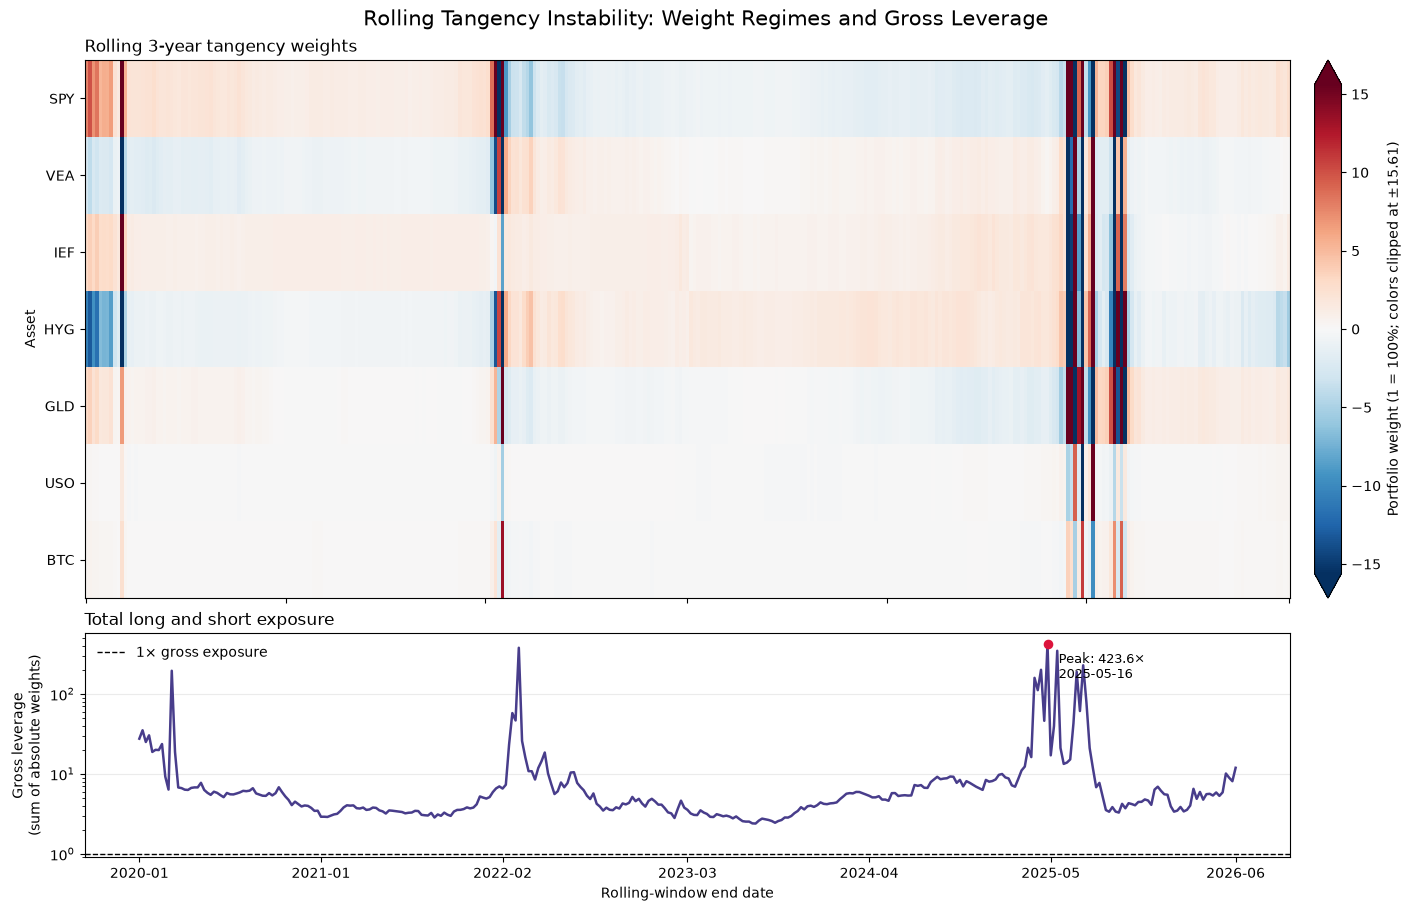

In [47]:
# 6.1 Re-estimate the tangency weights (all 7 assets) on rolling 3-year (156-week) windows

returns = all_returns.drop(columns=["SHV"])
window_size = 156  # 3 years of weekly data

rolling_weights = []
dates = returns.index[window_size - 1:]

for end in range(window_size, len(returns) + 1):
    win = returns.iloc[end - window_size:end]
    mu = win.mean().to_numpy()
    Sigma = win.cov().to_numpy()

    try:
        raw = np.linalg.inv(Sigma) @ mu
    except np.linalg.LinAlgError:
        raw = np.linalg.pinv(Sigma) @ mu

    w = raw / raw.sum()
    rolling_weights.append(pd.Series(w, index=returns.columns))

weights_df = pd.DataFrame(rolling_weights, index=dates)
weights_df.columns = returns.columns
display(weights_df.head())

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

# -----------------------------
# Prepare plotting quantities
# -----------------------------

# Gross leverage: total absolute long and short exposure
gross_leverage = weights_df.abs().sum(axis=1)

# Clip only the heatmap's color scale so isolated extreme weights
# do not hide the ordinary changes.
color_cap = np.nanquantile(
    np.abs(weights_df.to_numpy()),
    0.98
)

color_norm = TwoSlopeNorm(
    vmin=-color_cap,
    vcenter=0,
    vmax=color_cap
)

x_positions = np.arange(len(weights_df))

# Select readable date labels
tick_positions = np.linspace(
    0,
    len(weights_df) - 1,
    7,
    dtype=int
)

tick_labels = pd.to_datetime(
    weights_df.index[tick_positions]
).strftime("%Y-%m")


fig, (ax_weights, ax_leverage) = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    gridspec_kw={"height_ratios": [2.4, 1]},
    constrained_layout=True
)

fig.suptitle(
    "Rolling Tangency Instability: Weight Regimes and Gross Leverage",
    fontsize=15
)


# -----------------------------
# Panel 1: Weight heatmap
# -----------------------------

heatmap = ax_weights.imshow(
    weights_df.T,
    aspect="auto",
    origin="upper",
    cmap="RdBu_r",
    norm=color_norm,
    interpolation="nearest"
)

ax_weights.set_yticks(np.arange(len(weights_df.columns)))
ax_weights.set_yticklabels(weights_df.columns)

ax_weights.set_xticks(tick_positions)
ax_weights.set_xticklabels([])

ax_weights.set_ylabel("Asset")
ax_weights.set_title(
    "Rolling 3-year tangency weights",
    loc="left"
)

colorbar = fig.colorbar(
    heatmap,
    ax=ax_weights,
    pad=0.02,
    extend="both"
)

colorbar.set_label(
    f"Portfolio weight (1 = 100%; colors clipped at ±{color_cap:.2f})"
)


# -----------------------------
# Panel 2: Gross leverage
# -----------------------------

ax_leverage.plot(
    x_positions,
    gross_leverage.to_numpy(),
    color="darkslateblue",
    linewidth=1.8
)

# A fully invested long-only portfolio has gross leverage of 1
ax_leverage.axhline(
    1,
    color="black",
    linestyle="--",
    linewidth=1,
    label="1× gross exposure"
)

# Log scale keeps both normal and extreme leverage visible
ax_leverage.set_yscale("log")
ax_leverage.set_ylim(bottom=0.9)

ax_leverage.set_xticks(tick_positions)
ax_leverage.set_xticklabels(tick_labels)

ax_leverage.set_xlabel("Rolling-window end date")
ax_leverage.set_ylabel("Gross leverage\n(sum of absolute weights)")
ax_leverage.set_title(
    "Total long and short exposure",
    loc="left"
)

ax_leverage.grid(
    axis="y",
    alpha=0.25
)

ax_leverage.legend(
    loc="upper left",
    frameon=False
)


# Label the maximum-leverage observation
peak_position = gross_leverage.to_numpy().argmax()
peak_value = gross_leverage.iloc[peak_position]
peak_date = pd.to_datetime(gross_leverage.index[peak_position])

ax_leverage.scatter(
    peak_position,
    peak_value,
    color="crimson",
    s=35,
    zorder=3
)

ax_leverage.annotate(
    f"Peak: {peak_value:.1f}×\n{peak_date:%Y-%m-%d}",
    xy=(peak_position, peak_value),
    xytext=(8, -5),
    textcoords="offset points",
    ha="left",
    va="top",
    fontsize=9
)
plt.show()

In [39]:
# 6.2 Estimate the tangency weights on two subsamples: 2017-2019 and 2020-2021.
# Report both sets side by side.

# subsamples
returns1 = returns.loc["2017-01-13":"2019-12-27"]
returns2 = returns.loc["2020-01-03":"2021-12-31"]

# mean returns and volatility
mu1 = (returns1.mean()*52).to_numpy()
mu2 = (returns2.mean()*52).to_numpy()
Sigma1 = returns1.cov().to_numpy()
Sigma2 = returns2.cov().to_numpy()

# tangency weights
w1 = (np.linalg.inv(Sigma1) @ mu1)/(np.linalg.inv(Sigma1) @ mu1).sum()
w2 = (np.linalg.inv(Sigma2) @ mu2)/(np.linalg.inv(Sigma2) @ mu2).sum()
weights_df = pd.DataFrame([w1,w2],index = ["2017-2019", "2020-2021"])
weights_df.columns = returns.columns
display(weights_df.head())




,SPY,VEA,IEF,HYG,GLD,USO,BTC
2017-2019,10.818925,-3.605661,4.377172,-15.476237,3.995321,0.316463,0.574017
2020-2021,1.740708,-1.110353,1.087141,-0.744757,-0.067352,-0.070018,0.164631


The math of mean-variance is exact; the inputs are estimates.
* Which input is the bigger problem: the means or the covariance matrix?
* Given 6.1 and 6.2, why do practitioners constrain weights, shrink estimates, or fall back to simple rules?

## Answer 6.3

The estimated mean return will be the greater problem. Refer to the statistical analysis below of the weekly mean returns and volatility for both the 6.1 and 6.2 cases, the mean standard errors for the estimates of weekly returns are really large, matching the order of magnitude of the mean returns themselves. The 95% confidence interval also incorporates a large range. Therefore, the mean returns input for the tangency weight calculations are not reliable. 

The covariance matrix is also estimated with error, but variances and covariances are usually more stable than expected returns. But cases when the denominators are near zero can have great impact to the tangency weights.

The case of 6.1 shows that tangency weight method consistently produces weights that are highly leveraged in both short and long, and a small change in the data sample (difference in one week) can incur enormous portfolio re-adjustmenet with absolute weights suddenly adding up to over 100x leverage. The maximum gross exposure even reaches \(423.6\times\) on May 16, 2025

Section 6.2 gives the same message across longer subsamples. The 2017–2019 weights have about 40 times gross exposure, compared with 5 times for 2020–2021. SPY falls from 10.82 to 1.74, HYG changes from −15.48 to −0.74, and GLD changes from 4.00 to −0.07. Thus, the same optimization method applied to two reasonable historical periods produces substantially different allocations, leverage, and even investment directions.

Practitioners therefore constrain weights and gross leverage to prevent noisy estimates from producing unrealistic long and short positions, excessive turnover, and large transaction and financing costs. They shrink expected returns and covariances toward more stable targets so that sampling noise has less influence and produces more stable weights. 

In reality, simple rules such as equal weighting or 60/40 avoid relying heavily on estimated means and covariances. Although these approaches may have a lower in-sample Sharpe ratio, they are generally easier to implement and less likely to overfit one historical sample with controllable turnovers. 


In [46]:
import numpy as np
import pandas as pd


def mean_estimation_stats(sample):
    n = sample.count()

    weekly_mean = sample.mean()
    weekly_vol = sample.std(ddof=1)

    # Standard error of the estimated weekly mean
    mean_standard_error = weekly_vol / np.sqrt(n)

    # Approximate 95% confidence interval
    lower_95 = weekly_mean - 1.96 * mean_standard_error
    upper_95 = weekly_mean + 1.96 * mean_standard_error

    return pd.DataFrame({
        "Number of Weeks": n,
        "Weekly Mean": weekly_mean,
        "Weekly Volatility": weekly_vol,
        "Mean Standard Error": mean_standard_error,
        "95% CI Lower": lower_95,
        "95% CI Upper": upper_95,
        "Mean t-statistic": weekly_mean / mean_standard_error,
        "Annualized Mean": weekly_mean * 52,
        "Annualized Volatility": weekly_vol * np.sqrt(52)
    })

# Use the weekly excess-return data
returns1 = excess.loc["2017-01-01":"2019-12-31"]
returns2 = excess.loc["2020-01-01":"2021-12-31"]

stats1 = mean_estimation_stats(returns1)
stats2 = mean_estimation_stats(returns2)

display(
    stats1.style.format({
        "Number of Weeks": "{:.0f}",
        "Weekly Mean": "{:.3%}",
        "Weekly Volatility": "{:.3%}",
        "Mean Standard Error": "{:.3%}",
        "95% CI Lower": "{:.3%}",
        "95% CI Upper": "{:.3%}",
        "Mean t-statistic": "{:.2f}",
        "Annualized Mean": "{:.2%}",
        "Annualized Volatility": "{:.2%}"
    })
)

display(
    stats2.style.format({
        "Number of Weeks": "{:.0f}",
        "Weekly Mean": "{:.3%}",
        "Weekly Volatility": "{:.3%}",
        "Mean Standard Error": "{:.3%}",
        "95% CI Lower": "{:.3%}",
        "95% CI Upper": "{:.3%}",
        "Mean t-statistic": "{:.2f}",
        "Annualized Mean": "{:.2%}",
        "Annualized Volatility": "{:.2%}"
    })
)

,Number of Weeks,Weekly Mean,Weekly Volatility,Mean Standard Error,95% CI Lower,95% CI Upper,Mean t-statistic,Annualized Mean,Annualized Volatility
SPY,155,0.242%,1.773%,0.142%,-0.037%,0.521%,1.70,12.59%,12.78%
VEA,155,0.119%,1.588%,0.128%,-0.131%,0.369%,0.93,6.19%,11.45%
IEF,155,0.035%,0.645%,0.052%,-0.066%,0.137%,0.68,1.83%,4.65%
HYG,155,0.007%,0.675%,0.054%,-0.099%,0.113%,0.13,0.36%,4.87%
GLD,155,0.165%,1.384%,0.111%,-0.053%,0.383%,1.49,8.59%,9.98%
USO,155,0.140%,3.893%,0.313%,-0.473%,0.753%,0.45,7.28%,28.07%
BTC,155,1.999%,11.582%,0.930%,0.176%,3.823%,2.15,103.96%,83.52%


,Number of Weeks,Weekly Mean,Weekly Volatility,Mean Standard Error,95% CI Lower,95% CI Upper,Mean t-statistic,Annualized Mean,Annualized Volatility
SPY,105,0.424%,3.336%,0.326%,-0.214%,1.062%,1.30,22.06%,24.06%
VEA,105,0.195%,3.336%,0.326%,-0.443%,0.833%,0.60,10.12%,24.05%
IEF,105,0.039%,0.737%,0.072%,-0.102%,0.180%,0.55,2.04%,5.32%
HYG,105,0.017%,2.326%,0.227%,-0.428%,0.462%,0.07,0.87%,16.77%
GLD,105,0.204%,2.418%,0.236%,-0.259%,0.667%,0.86,10.61%,17.44%
USO,105,-0.246%,8.200%,0.800%,-1.814%,1.323%,-0.31,-12.77%,59.13%
BTC,105,2.353%,10.718%,1.046%,0.302%,4.403%,2.25,122.33%,77.29%
